In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_groq import ChatGroq


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="llama-3.1-8b-instant",)

In [9]:
# Create State
class BlogState(TypedDict):
    topic: str
    outline : str
    blog: str


In [7]:
def gen_outline(state:BlogState) -> BlogState:
    # Extract topic from state
    topic = state['topic']
    # Generate Prompt
    prompt = f'Generate an outline for a blog on topic - {topic}'
    # Call LLM to generate outline
    outline = model.invoke(prompt).content
    # Update State
    state['outline'] = outline

    return state

In [10]:
def gen_blog(state:BlogState) -> BlogState:
    # Extract outline from state
    topic = state['topic']
    outline = state['outline']
    # Generate Prompt
    prompt = f'Generate a blog for  topic - {topic} using following outline\n {outline}'
    # Call LLM to generate outline
    blog = model.invoke(prompt).content
    # Update State
    state['blog'] = blog

    return state

In [12]:
# Create Graph
graph = StateGraph(BlogState)

# Add Nodes to the graph
graph.add_node('gen_outline',gen_outline)
graph.add_node('gen_blog',gen_blog)

# Add edges in the graph
graph.add_edge(START,'gen_outline')
graph.add_edge('gen_outline','gen_blog')
graph.add_edge('gen_blog',END)

# Compile Graph
workflow= graph.compile()


In [13]:
# Execute Graph
initial_state = {'topic': 'Agentic Ai'} 
final_state = workflow.invoke(initial_state)
print(final_state)

{'topic': 'Agentic Ai', 'outline': '**Title:** "Unlocking the Power of Agentic AI: Understanding the Future of Artificial Intelligence"\n\n**I. Introduction**\n\n* Definition of Agentic AI\n* Brief overview of the importance and potential of Agentic AI\n* Thesis statement: Agentic AI has the potential to revolutionize industries and transform the way we interact with technology, but it also raises significant concerns about accountability, ethics, and control.\n\n**II. What is Agentic AI?**\n\n* Historical context: From reactive to proactive AI\n* Key characteristics of Agentic AI:\n + Autonomy\n + Self-awareness\n + Goal-directed behavior\n + Ability to learn and adapt\n* Examples of Agentic AI in action:\n + Personal assistants like Siri and Alexa\n + Autonomous vehicles\n + Intelligent robots\n\n**III. Benefits of Agentic AI**\n\n* Increased efficiency and productivity\n* Improved decision-making and problem-solving\n* Enhanced customer experience\n* Potential for new business model

In [14]:
print(final_state['blog'])

**Unlocking the Power of Agentic AI: Understanding the Future of Artificial Intelligence**

As we continue to push the boundaries of artificial intelligence, a new paradigm is emerging: Agentic AI. This revolutionary technology has the potential to transform industries and transform the way we interact with technology, but it also raises significant concerns about accountability, ethics, and control. In this blog, we will delve into the world of Agentic AI, exploring its definition, benefits, challenges, and future prospects.

**I. Introduction**

Agentic AI refers to a type of artificial intelligence that is capable of autonomous decision-making, self-awareness, and goal-directed behavior. It is a significant departure from traditional AI, which was primarily designed to react to predefined rules and inputs. Agentic AI has the potential to revolutionize industries such as healthcare, finance, and manufacturing, but it also raises important questions about accountability and responsibi

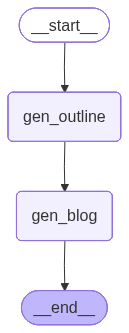

In [15]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())